# Notebook for the 1000 Runs Ensemble

In [11]:
import pandas as pd
import os
from utils.eda_utils import EDAUtils
import boto3
import numpy as np

import re
from io import BytesIO
from urllib.parse import urlparse
from typing import List, Optional, Tuple

from botocore.config import Config
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
from functools import partial


In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(ROOT_DIR_PATH, "config")

In [14]:
os.makedirs(SSP_DIR_PATH, exist_ok=True)

In [15]:
edau = EDAUtils()

## Pull data from AWS S3


In [16]:
aws_config = edau.read_yaml(os.path.join(CONFIG_DIR_PATH, "aws_credentials_config.yaml"))
profile_name = aws_config["profile_name"]
bucket_name = aws_config["bucket_name"]
# Set your profile
session = boto3.Session(profile_name=profile_name)

# Create an S3 client or resource
s3 = session.resource('s3')

run_id = "sisepuede_run_2025-10-07t13;30;14.193421"

# Define folder prefix
prefix = f'transfers/{run_id}/'  # this is like the "folder" in S3

In [17]:
# Local destination
destination = os.path.join(SSP_DIR_PATH, run_id)
if os.path.exists(destination) and os.listdir(destination):
    print(f"Destination '{destination}' already exists and is not empty. Skipping download.")
else:
    os.makedirs(destination, exist_ok=True)
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=prefix):
        if obj.key.endswith('/') or "transformations" in obj.key:  # skip directories and transformations
            continue
        target_path = os.path.join(destination, os.path.basename(obj.key))
        print(f"Downloading {obj.key} to {target_path}")
        bucket.download_file(obj.key, target_path)

Destination '/Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/data/ssp/sisepuede_run_2025-10-07t13;30;14.193421' already exists and is not empty. Skipping download.


In [18]:
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)
print(SIMULATION_DIR_PATH)

/Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/data/ssp/sisepuede_run_2025-10-07t13;30;14.193421


In [19]:

# -------- helpers --------

def _parse_s3_uri(s3_uri: str) -> Tuple[str, str]:
    if not s3_uri.startswith("s3://"):
        raise ValueError(f"Invalid S3 URI: {s3_uri}")
    parsed = urlparse(s3_uri)
    return parsed.netloc, parsed.path.lstrip("/")


def _list_s3_keys(bucket: str, prefix: str, client, filename_regex: Optional[str]) -> List[str]:
    paginator = client.get_paginator("list_objects_v2")
    keys: List[str] = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith("/"):
                continue
            if filename_regex:
                name = key.rsplit("/", 1)[-1]
                if not re.search(filename_regex, name):
                    continue
            keys.append(key)
    return keys


_ID_RE = re.compile(r"(?:cb|emission)_(\d+)", re.IGNORECASE)

def _sort_keys_for_stability(keys: List[str]) -> List[str]:
    def key_fn(k: str):
        name = k.rsplit("/", 1)[-1]
        m = _ID_RE.search(name)
        return (0, int(m.group(1))) if m else (1, name.lower())
    return sorted(keys, key=key_fn)


def _download_object_bytes(bucket: str, key: str, client, retries: int = 3) -> bytes:
    last_err = None
    for _ in range(retries):
        try:
            return client.get_object(Bucket=bucket, Key=key)["Body"].read()
        except Exception as e:
            last_err = e
    raise last_err


def _parse_csv_bytes(csv_bytes: bytes, **read_csv_kwargs) -> pd.DataFrame:
    return pd.read_csv(BytesIO(csv_bytes), **(read_csv_kwargs or {}))


# -------- main function --------

def concat_csvs_from_s3_parallel(
    s3_uri: str,
    max_files: Optional[int] = 200,
    fetch_all: bool = False,
    filename_regex: Optional[str] = r"^(cb|emission)_.+\.csv(\.gz)?$",
    profile_name: Optional[str] = None,
    region_name: Optional[str] = None,
    # I/O parallelism (threads)
    io_workers: int = 16,
    # Parsing parallelism (processes). Set to 0/1 to parse in main thread.
    parse_workers: int = 0,
    # boto3 config
    max_pool_connections: int = 64,
    # pandas.read_csv kwargs
    read_csv_kwargs: Optional[dict] = None,
    # memory/robustness
    fail_fast: bool = False,       # if True, raise on first download/parse error
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Parallel S3 download + (optional) parallel CSV parsing, then concatenation.

    Parameters
    ----------
    s3_uri : str
        S3 "folder" URI (e.g., s3://bucket/prefix/).
    max_files : int, optional
        Number of files from the start of the sorted list (ignored if fetch_all=True).
    fetch_all : bool
        If True, fetch all files matching filename_regex.
    filename_regex : str, optional
        Filter filenames. Default matches cb_*.csv and emission_*.csv (optionally .gz).
    profile_name, region_name : str, optional
        AWS session selection.
    io_workers : int
        Threads for S3 downloads (network-bound).
    parse_workers : int
        Processes for CSV parsing (CPU-bound). 0 or 1 disables process pool.
    max_pool_connections : int
        Boto3 underlying HTTP connection pool size.
    read_csv_kwargs : dict, optional
        Passed to pandas.read_csv (e.g., {"low_memory": False}).
    fail_fast : bool
        If True, any failed file aborts the whole run with an exception.
    verbose : bool
        Print progress/info.

    Returns
    -------
    pd.DataFrame
        Concatenated dataframe (union of columns). Empty if no files found.
    """
    # --- setup session and client ---
    session = boto3.Session(profile_name=profile_name, region_name=region_name)
    client = session.client("s3", config=Config(max_pool_connections=max_pool_connections))

    # --- discover keys ---
    bucket, prefix = _parse_s3_uri(s3_uri)
    keys = _list_s3_keys(bucket, prefix, client, filename_regex)
    if not keys:
        if verbose: print(f"[INFO] No files found under {s3_uri} (regex={filename_regex!r}).")
        return pd.DataFrame()

    keys = _sort_keys_for_stability(keys)
    if not fetch_all:
        n = max_files if (max_files and max_files > 0) else 200
        keys = keys[:n]

    if verbose: print(f"[INFO] Downloading {len(keys)} file(s) from s3://{bucket}/{prefix} with {io_workers} I/O threads.")

    # --- stage 1: download bytes in parallel threads ---
    csv_bytes_list = [None] * len(keys)  # keep order aligned with keys
    errors = []

    def _dl(idx_key):
        idx, key = idx_key
        try:
            csv_bytes_list[idx] = _download_object_bytes(bucket, key, client)
        except Exception as e:
            msg = f"Download failed for {key}: {e}"
            if fail_fast:
                raise RuntimeError(msg) from e
            errors.append(msg)
            if verbose: print(f"[WARN] {msg}")

    with ThreadPoolExecutor(max_workers=io_workers) as ex:
        for _ in as_completed([ex.submit(_dl, (i, k)) for i, k in enumerate(keys)]):
            pass

    if errors and fail_fast:
        raise RuntimeError(errors[0])
    # drop failed ones
    ok_pairs = [(k, b) for k, b in zip(keys, csv_bytes_list) if b is not None]
    if not ok_pairs:
        if verbose: print("[INFO] All downloads failed.")
        return pd.DataFrame()
    if verbose and errors: print(f"[INFO] {len(errors)} file(s) failed to download; continuing with {len(ok_pairs)}.")

    # --- stage 2: parse CSVs (optionally in processes) ---
    read_csv_kwargs = read_csv_kwargs or {}
    dfs: List[pd.DataFrame] = []
    parse_errors = []

    if parse_workers and parse_workers > 1:
        if verbose: print(f"[INFO] Parsing CSVs with {parse_workers} process(es).")
        parse_fn = partial(_parse_csv_bytes, **read_csv_kwargs)
        with ProcessPoolExecutor(max_workers=parse_workers) as pex:
            fut2key = {pex.submit(parse_fn, b): k for k, b in ok_pairs}
            for fut in as_completed(fut2key):
                key = fut2key[fut]
                try:
                    dfs.append(fut.result())
                except Exception as e:
                    msg = f"Parse failed for {key}: {e}"
                    if fail_fast:
                        raise RuntimeError(msg) from e
                    parse_errors.append(msg)
                    if verbose: print(f"[WARN] {msg}")
    else:
        if verbose: print("[INFO] Parsing CSVs in main process.")
        for key, b in ok_pairs:
            try:
                dfs.append(_parse_csv_bytes(b, **read_csv_kwargs))
            except Exception as e:
                msg = f"Parse failed for {key}: {e}"
                if fail_fast:
                    raise RuntimeError(msg) from e
                parse_errors.append(msg)
                if verbose: print(f"[WARN] {msg}")

    if not dfs:
        if verbose: print("[INFO] No CSVs parsed successfully.")
        return pd.DataFrame()
    if verbose and parse_errors:
        print(f"[INFO] {len(parse_errors)} file(s) failed to parse; concatenating {len(dfs)} dataframe(s).")

    out = pd.concat(dfs, ignore_index=True, sort=False)
    if verbose: print(f"[INFO] Concatenated shape: {out.shape}")
    return out


In [21]:
decomposed_s3_uri = "s3://sisepuede-data/run_database/sisepuede_run_2025-10-07t13;30;14.193421/decomposed_outputs/"
cb_s3_uri = "s3://sisepuede-data/run_database/sisepuede_run_2025-10-07t13;30;14.193421/cb_outputs/"

# A) First 200 files, threaded I/O + single-process parsing
decomposed_df = concat_csvs_from_s3_parallel(
    decomposed_s3_uri,
    max_files=200,
    fetch_all=False,
    profile_name=profile_name,
    io_workers=24,                 # increase if you have bandwidth
    parse_workers=0,               # 0/1 => parse in main process
    read_csv_kwargs={"low_memory": False}
)

cb_df = concat_csvs_from_s3_parallel(
    cb_s3_uri,
    max_files=200,
    fetch_all=False,
    profile_name=profile_name,
    io_workers=24,                 # increase if you have bandwidth
    parse_workers=0,               # 0/1 => parse in main process
    read_csv_kwargs={"low_memory": False},
)

# # B) All files, threaded I/O + multi-process parsing (faster on big CSVs/CPUs)
# df_all = concat_csvs_from_s3_parallel(
#     s3_uri,
#     fetch_all=True,
#     io_workers=32,
#     parse_workers=8,               # try ~ number of CPU cores
#     read_csv_kwargs={"low_memory": False},
# )

# # C) Narrow by regex if needed (keeps stability sort by numeric IDs)
# df_cb_only = concat_csvs_from_s3_parallel(
#     s3_uri,
#     fetch_all=True,
#     filename_regex=r"^cb_\d+\.csv(\.gz)?$",
#     io_workers=16,
#     parse_workers=4,
# )


[INFO] Downloading 200 file(s) from s3://sisepuede-data/run_database/sisepuede_run_2025-10-07t13;30;14.193421/decomposed_outputs/ with 24 I/O threads.
[INFO] Parsing CSVs in main process.
[INFO] Concatenated shape: (5800, 469)
[INFO] Downloading 200 file(s) from s3://sisepuede-data/run_database/sisepuede_run_2025-10-07t13;30;14.193421/cb_outputs/ with 24 I/O threads.
[INFO] Parsing CSVs in main process.
[INFO] Concatenated shape: (5800, 6)


## Load and Process LHC Samples Dataframes

In [22]:
# Load lhc samples dfs
lhs_exogenous_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES.csv"))
lhs_levers_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_LHC_SAMPLES_LEVER_EFFECTS.csv"))

In [23]:
# Check design ids
lhs_exogenous_df.head()

,region,design_id,future_id,46,47,48,49,50,51,52,53,54,55,56,57,58,59
0,louisiana,-1,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,0.609931,0.110602,0.228879,0.023251,0.519864
1,louisiana,-1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,0.646620,0.890292,0.243776,0.881897,0.307468
2,louisiana,-1,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,0.197423,0.228748,0.148648,0.914823,0.078667
3,louisiana,-1,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,0.268124,0.114697,0.215141,0.400283,0.013558
4,louisiana,-1,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,0.418552,0.042683,0.369231,0.453588,0.800351


In [24]:
lhs_exogenous_df.design_id.unique()

array([-1,  4])

In [25]:
lhs_levers_df.head()

,region,design_id,future_id,1,2,3,4,5,6,7,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
0,louisiana,-1,1,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
1,louisiana,-1,2,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
2,louisiana,-1,3,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
3,louisiana,-1,4,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
4,louisiana,-1,5,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


In [26]:
lhs_levers_df.design_id.unique()

array([-1,  4])

In [27]:
# print shapes
print(lhs_exogenous_df.shape)
print(lhs_levers_df.shape)

(200000, 17)
(200000, 68)


In [28]:
lhs_df_merged = pd.merge(lhs_exogenous_df, lhs_levers_df, on=["region", "design_id", "future_id"], how="outer", suffixes=('_X', '_L'))
lhs_df_merged.head()

,region,design_id,future_id,46,47,48,49,50,51,52,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
0,louisiana,-1,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
1,louisiana,-1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
2,louisiana,-1,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
3,louisiana,-1,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
4,louisiana,-1,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


In [29]:
# Filter the lhs_df_merged to only include rows where design_id is 4
lhs_df_merged = lhs_df_merged[lhs_df_merged.design_id == 4]
lhs_df_merged.shape

(100000, 82)

In [30]:
lhs_df_merged.design_id.unique()

array([4])

In [31]:
# NOTE: check col names, there should be no duplicates
lhs_df_merged.columns

Index(['region', 'design_id', 'future_id', '46', '47', '48', '49', '50', '51',
       '52', '53', '54', '55', '56', '57', '58', '59', '1', '2', '3', '4', '5',
       '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17',
       '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
       '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41',
       '42', '43', '44', '45', '1714', '1715', '1718', '1720', '1723', '1740',
       '1741', '1744', '1747', '1749', '1761', '1762', '1767', '1768', '1770',
       '1778', '1780', '1792', '1793', '1801'],
      dtype='object')

In [32]:
lhs_df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 100000 to 199999
Data columns (total 82 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   region     100000 non-null  object 
 1   design_id  100000 non-null  int64  
 2   future_id  100000 non-null  int64  
 3   46         100000 non-null  float64
 4   47         100000 non-null  float64
 5   48         100000 non-null  float64
 6   49         100000 non-null  float64
 7   50         100000 non-null  float64
 8   51         100000 non-null  float64
 9   52         100000 non-null  float64
 10  53         100000 non-null  float64
 11  54         100000 non-null  float64
 12  55         100000 non-null  float64
 13  56         100000 non-null  float64
 14  57         100000 non-null  float64
 15  58         100000 non-null  float64
 16  59         100000 non-null  float64
 17  1          100000 non-null  float64
 18  2          100000 non-null  float64
 19  3          100000 non-n

## Load SISEPUEDE WIDE_INPUTS_OUTPUTS

In [33]:
decomposed_df.head()

,primary_id,time_period,total_emissions,efficfactor_enfu_industrial_energy_fuel_biomass,efficfactor_enfu_industrial_energy_fuel_coal,efficfactor_enfu_industrial_energy_fuel_coke,efficfactor_enfu_industrial_energy_fuel_diesel,efficfactor_enfu_industrial_energy_fuel_electricity,efficfactor_enfu_industrial_energy_fuel_furnace_gas,efficfactor_enfu_industrial_energy_fuel_gasoline,...,totalvalue_enfu_fuel_consumed_inen_fuel_coke,totalvalue_enfu_fuel_consumed_inen_fuel_diesel,totalvalue_enfu_fuel_consumed_inen_fuel_electricity,totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas,totalvalue_enfu_fuel_consumed_inen_fuel_gasoline,totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids,totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen,totalvalue_enfu_fuel_consumed_inen_fuel_kerosene,totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas,totalvalue_enfu_fuel_consumed_inen_fuel_oil
0,36800368,7,192.501062,0.602414,0.602414,0.602414,0.753018,2.409658,0.803219,0.753018,...,0.404062,178.601128,1174.317781,5.268705e+07,181.622909,0,0.317356,0,1997.361189,276.982160
1,36800368,8,187.719262,0.604839,0.604839,0.604839,0.756048,2.419355,0.806452,0.756048,...,0.061134,182.504394,1145.385420,5.254285e+07,175.198697,0,0.356350,0,1756.982222,290.281161
2,36800368,9,189.224632,0.607273,0.607273,0.607273,0.759091,2.429091,0.809697,0.759091,...,0.022939,194.993152,1136.290977,5.163389e+07,180.826891,0,0.374174,0,1717.637258,310.608648
3,36800368,10,189.818129,0.609716,0.609716,0.609716,0.762146,2.438866,0.812955,0.762146,...,0.018743,195.487695,1113.543102,5.045960e+07,180.184554,0,0.402038,0,1748.397107,310.009898
4,36800368,11,190.762750,0.612170,0.612170,0.612170,0.765213,2.448680,0.816227,0.765213,...,0.014263,195.467729,1104.997405,4.920852e+07,177.840154,0,0.424731,0,1784.410018,304.599276


In [34]:
decomposed_df.primary_id.nunique()

200

## Load Costs-Benefits Data

In [35]:
cb_df.head()

,primary_id,future_id,strategy_code,Year,air_pollution,technical_cost
0,43800438,0,PFLO:ALL_LA_ACTIONS,2022.0,0.0,0.0
1,43800438,0,PFLO:ALL_LA_ACTIONS,2023.0,0.0,0.0
2,43800438,0,PFLO:ALL_LA_ACTIONS,2024.0,0.0,0.0
3,43800438,0,PFLO:ALL_LA_ACTIONS,2025.0,0.0,-inf
4,43800438,0,PFLO:ALL_LA_ACTIONS,2026.0,0.0,-inf


In [36]:
cb_df.future_id.nunique()

200

In [37]:
cb_df.primary_id.nunique()

200

## Data Cleaning

### Production Data

In [38]:
# Get the subsector total variables
industry_value_fuel_vars = [c for c in decomposed_df.columns if "totalvalue_enfu_fuel_consumed_inen" in c]
industry_value_fuel_vars

['totalvalue_enfu_fuel_consumed_inen_fuel_biomass',
 'totalvalue_enfu_fuel_consumed_inen_fuel_coal',
 'totalvalue_enfu_fuel_consumed_inen_fuel_coke',
 'totalvalue_enfu_fuel_consumed_inen_fuel_diesel',
 'totalvalue_enfu_fuel_consumed_inen_fuel_electricity',
 'totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas',
 'totalvalue_enfu_fuel_consumed_inen_fuel_gasoline',
 'totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids',
 'totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen',
 'totalvalue_enfu_fuel_consumed_inen_fuel_kerosene',
 'totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas',
 'totalvalue_enfu_fuel_consumed_inen_fuel_oil']

In [39]:
# Filter to only production columns avoiding "subsector" total columns
industrial_production_df =decomposed_df[["primary_id", "time_period"] + industry_value_fuel_vars]
industrial_production_df

,primary_id,time_period,totalvalue_enfu_fuel_consumed_inen_fuel_biomass,totalvalue_enfu_fuel_consumed_inen_fuel_coal,totalvalue_enfu_fuel_consumed_inen_fuel_coke,totalvalue_enfu_fuel_consumed_inen_fuel_diesel,totalvalue_enfu_fuel_consumed_inen_fuel_electricity,totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas,totalvalue_enfu_fuel_consumed_inen_fuel_gasoline,totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids,totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen,totalvalue_enfu_fuel_consumed_inen_fuel_kerosene,totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas,totalvalue_enfu_fuel_consumed_inen_fuel_oil
0,36800368,7,1262.298646,3.671070,0.404062,178.601128,1174.317781,5.268705e+07,181.622909,0,0.317356,0,1997.361189,276.982160
1,36800368,8,1251.052218,0.581992,0.061134,182.504394,1145.385420,5.254285e+07,175.198697,0,0.356350,0,1756.982222,290.281161
2,36800368,9,1245.665599,0.235821,0.022939,194.993152,1136.290977,5.163389e+07,180.826891,0,0.374174,0,1717.637258,310.608648
3,36800368,10,1229.758025,0.195703,0.018743,195.487695,1113.543102,5.045960e+07,180.184554,0,0.402038,0,1748.397107,310.009898
4,36800368,11,1209.681771,0.153169,0.014263,195.467729,1104.997405,4.920852e+07,177.840154,0,0.424731,0,1784.410018,304.599276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5795,43800638,31,407.467113,0.000000,0.000000,151.838963,4337.794406,2.522337e+07,148.848122,0,65.820832,0,1737.773338,320.879074
5796,43800638,32,377.373300,0.000000,0.000000,150.384086,4424.664276,2.472515e+07,147.472185,0,65.557057,0,1742.317942,319.925441
5797,43800638,33,347.384030,0.000000,0.000000,148.320986,4514.278337,2.426527e+07,146.077512,0,65.171886,0,1752.979700,317.744439
5798,43800638,34,317.588321,0.000000,0.000000,146.949187,4581.480203,2.383818e+07,143.761383,0,64.663274,0,1757.905665,316.233575


In [40]:
# 2) Define your fuels and sectors
relevant_fuels = ['solid_biomass',
                  'biomass',
                    'coal', 
                    'coke', 
                    'diesel', 
                    'electricity',
                    'furnace_gas',
                    'gasoline', 
                    'hydrocarbon_gas_liquids',
                    'hydrogen',
                    'kerosene',
                    'natural_gas',
                    'oil']

sectors = ['agriculture_and_livestock',
           'cement',
           'chemicals',
           'electronics',
           'glass',
           'lime_and_carbonite',
           'metals',
           'mining',
           'other_product_manufacturing',
           'paper',
           'plastic',
           'recycled_glass',
           'recycled_metals',
           'recycled_paper',
           'recycled_plastic',
           'recycled_rubber_and_leather',
           'recycled_textiles',
           'recycled_wood',
           'rubber_and_leather',
           'textiles',
           'wood']

In [41]:
# 4) Industrial cost parameters
capex_industrial_electricity = 92666.6 * 21
capex_industrial_other       = 92666.6 * 12
opex_industrial_electricity  = 92666.6 * 2.5
opex_industrial_other        = 92666.6 * 4.5
capex_multiplier_efficiency = 10000000
opex_multiplier_efficiency = 0

In [42]:
[col for col in decomposed_df.columns if col.startswith("totalvalue_enfu_fuel_consumed_inen_")]

['totalvalue_enfu_fuel_consumed_inen_fuel_biomass',
 'totalvalue_enfu_fuel_consumed_inen_fuel_coal',
 'totalvalue_enfu_fuel_consumed_inen_fuel_coke',
 'totalvalue_enfu_fuel_consumed_inen_fuel_diesel',
 'totalvalue_enfu_fuel_consumed_inen_fuel_electricity',
 'totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas',
 'totalvalue_enfu_fuel_consumed_inen_fuel_gasoline',
 'totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids',
 'totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen',
 'totalvalue_enfu_fuel_consumed_inen_fuel_kerosene',
 'totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas',
 'totalvalue_enfu_fuel_consumed_inen_fuel_oil']

In [43]:
decomposed_df[[col for col in decomposed_df.columns if col.startswith("totalvalue_enfu_fuel_consumed_inen")]]

,totalvalue_enfu_fuel_consumed_inen_fuel_biomass,totalvalue_enfu_fuel_consumed_inen_fuel_coal,totalvalue_enfu_fuel_consumed_inen_fuel_coke,totalvalue_enfu_fuel_consumed_inen_fuel_diesel,totalvalue_enfu_fuel_consumed_inen_fuel_electricity,totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas,totalvalue_enfu_fuel_consumed_inen_fuel_gasoline,totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids,totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen,totalvalue_enfu_fuel_consumed_inen_fuel_kerosene,totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas,totalvalue_enfu_fuel_consumed_inen_fuel_oil
0,1262.298646,3.671070,0.404062,178.601128,1174.317781,5.268705e+07,181.622909,0,0.317356,0,1997.361189,276.982160
1,1251.052218,0.581992,0.061134,182.504394,1145.385420,5.254285e+07,175.198697,0,0.356350,0,1756.982222,290.281161
2,1245.665599,0.235821,0.022939,194.993152,1136.290977,5.163389e+07,180.826891,0,0.374174,0,1717.637258,310.608648
3,1229.758025,0.195703,0.018743,195.487695,1113.543102,5.045960e+07,180.184554,0,0.402038,0,1748.397107,310.009898
4,1209.681771,0.153169,0.014263,195.467729,1104.997405,4.920852e+07,177.840154,0,0.424731,0,1784.410018,304.599276
...,...,...,...,...,...,...,...,...,...,...,...,...
5795,407.467113,0.000000,0.000000,151.838963,4337.794406,2.522337e+07,148.848122,0,65.820832,0,1737.773338,320.879074
5796,377.373300,0.000000,0.000000,150.384086,4424.664276,2.472515e+07,147.472185,0,65.557057,0,1742.317942,319.925441
5797,347.384030,0.000000,0.000000,148.320986,4514.278337,2.426527e+07,146.077512,0,65.171886,0,1752.979700,317.744439
5798,317.588321,0.000000,0.000000,146.949187,4581.480203,2.383818e+07,143.761383,0,64.663274,0,1757.905665,316.233575


In [44]:
# ---------- quick headline checks ----------
print("\n=== HEADLINE CHECKS ===")
print(f"rows={len(decomposed_df):,}, cols={len(decomposed_df.columns):,}")
print("unique primary_id:", decomposed_df['primary_id'].nunique())
tp_min = decomposed_df['time_period'].min()
tp_max = decomposed_df['time_period'].max()
print(f"time_period range: {tp_min}..{tp_max}")
print("sample columns (first 20):", list(decomposed_df.columns[:20]))

# ensure numeric for operations (you can add more patterns here if needed)
def _to_numeric_safe(s: pd.Series, name: str) -> pd.Series:
    out = pd.to_numeric(s, errors="coerce")
    if out.isna().any():
        na_pct = 100 * out.isna().mean()
        print(f"[WARN] Column '{name}' has {na_pct:.1f}% NaNs after numeric coercion.")
    return out

# precompute earliest time_period per primary_id for baseline logic
earliest_tp = decomposed_df.groupby('primary_id')['time_period'].transform('min')

# Initialize results dataframe
ind_fuel_demand_by_sector = pd.DataFrame({
    'primary_id': decomposed_df['primary_id'],
    'time_period': decomposed_df['time_period']
}, index=decomposed_df.index)

added_cols = []  # track what we actually add

print("\n=== EFFICIENCY COLUMN SCAN ===")
for fuel in relevant_fuels:
    eff_cols = [c for c in decomposed_df.columns
                if c.startswith(f'efficfactor_enfu_industrial_energy_fuel_{fuel}')]
    if not eff_cols:
        print(f"[SKIP] fuel='{fuel}': no efficiency column matching 'efficfactor_enfu_industrial_energy_fuel_{fuel}*'")
        continue

    if len(eff_cols) > 1:
        print(f"[NOTE] fuel='{fuel}': multiple efficiency cols found, using first:", eff_cols)

    fuel_efficiency_raw = decomposed_df[eff_cols[0]]
    fuel_efficiency = _to_numeric_safe(fuel_efficiency_raw, eff_cols[0])

    # guard against zeros / negatives in efficiency
    zero_eff = (fuel_efficiency <= 0) | fuel_efficiency.isna()
    if zero_eff.any():
        zc = int(zero_eff.sum())
        print(f"[WARN] fuel='{fuel}': {zc} efficiency values are <=0 or NaN. Will avoid division by zero and set outputs to NaN there.")

    # ------ per sector ------
    for sector in sectors:
        # match sector demand and fraction columns
        sector_dem_cols = [c for c in decomposed_df.columns
                           if f'energy_demand_inen_{sector}' in c]
        sector_fuel_fraction_cols = [c for c in decomposed_df.columns
                                     if f'frac_inen_energy_{sector}_{fuel}' in c]

        print(f"\n[fuel={fuel} | sector={sector}]")
        print("  demand cols  :", sector_dem_cols[:3], ("(+more)" if len(sector_dem_cols) > 3 else ""))
        print("  fraction cols:", sector_fuel_fraction_cols[:3], ("(+more)" if len(sector_fuel_fraction_cols) > 3 else ""))

        if not sector_dem_cols:
            print("  -> SKIP: no sector demand column found matching 'energy_demand_inen_{sector}*'")
            continue
        if not sector_fuel_fraction_cols:
            print(f"  -> SKIP: no sector fuel fraction column found matching 'frac_inen_energy_{sector}_{fuel}*'")
            continue

        if len(sector_dem_cols) > 1:
            print("  [NOTE] multiple demand cols; using first:", sector_dem_cols[0])
        if len(sector_fuel_fraction_cols) > 1:
            print("  [NOTE] multiple fraction cols; using first:", sector_fuel_fraction_cols[0])

        sector_total_demand = _to_numeric_safe(decomposed_df[sector_dem_cols[0]], sector_dem_cols[0])
        sector_fuel_fraction = _to_numeric_safe(decomposed_df[sector_fuel_fraction_cols[0]], sector_fuel_fraction_cols[0])

        # sanity on shares
        nonfinite_share = sector_fuel_fraction.isna().sum()
        if nonfinite_share:
            print(f"  [WARN] fraction NaNs: {nonfinite_share}")

        # quick mass check
        mass = float((sector_fuel_fraction * sector_total_demand).sum(skipna=True))
        print(f"  product sum (fraction*demand) = {mass:,.3f}")

        # your guard: allow electricity even if zero
        if mass <= 0 and fuel != 'electricity':
            print("  -> SKIP: product sum ≤ 0 and fuel != electricity")
            continue

        # compute sector fuel demand
        sector_fuel_demand = sector_fuel_fraction * sector_total_demand
        ind_fuel_demand_by_sector[f'energy_demand_{sector}_{fuel}'] = sector_fuel_demand
        added_cols.append(f'energy_demand_{sector}_{fuel}')

        # CAPEX / OPEX
        if fuel == 'electricity':
            ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = sector_fuel_demand * capex_industrial_electricity
            ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}']  = sector_fuel_demand * opex_industrial_electricity
            added_cols += [f'energy_demand_capex_{sector}_{fuel}', f'energy_demand_opex_{sector}_{fuel}']
        else:
            ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = sector_fuel_demand * capex_industrial_other
            ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}']  = sector_fuel_demand * opex_industrial_other
            added_cols += [f'energy_demand_capex_{sector}_{fuel}', f'energy_demand_opex_{sector}_{fuel}']

        # Fuel consumed (avoid div by zero)
        # Set result to NaN where efficiency is <=0 or NaN
        safe_eff = fuel_efficiency.mask(zero_eff, np.nan)
        sector_fuel_consumed = sector_fuel_demand / safe_eff

        # Baseline = earliest time_period per primary_id
        is_earliest = (decomposed_df['time_period'] == earliest_tp)
        # pick the value at earliest tp; broadcast within group
        baseline_vals = sector_fuel_consumed.where(is_earliest)
        sector_fuel_consumed_baseline = baseline_vals.groupby(decomposed_df['primary_id']).transform('first')

        # Change relative to baseline (baseline - current)
        sector_change_in_fuel_consumed = sector_fuel_consumed_baseline - sector_fuel_consumed

        # Save results
        ind_fuel_demand_by_sector[f'efficiency_energy_saving_{sector}_{fuel}'] = sector_change_in_fuel_consumed
        ind_fuel_demand_by_sector[f'efficiency_capex_{sector}_{fuel}'] = sector_change_in_fuel_consumed * capex_multiplier_efficiency
        ind_fuel_demand_by_sector[f'efficiency_opex_{sector}_{fuel}'] = sector_change_in_fuel_consumed * opex_multiplier_efficiency
        added_cols += [
            f'efficiency_energy_saving_{sector}_{fuel}',
            f'efficiency_capex_{sector}_{fuel}',
            f'efficiency_opex_{sector}_{fuel}',
        ]

# ---------- post-run summary ----------
print("\n=== POST-RUN SUMMARY ===")
print(f"Added {len(added_cols)} columns.")
if added_cols:
    # show first few with nonzero counts to prove something was written
    nz = []
    for c in added_cols:
        vals = pd.to_numeric(ind_fuel_demand_by_sector[c], errors="coerce")
        nz_count = int((vals.fillna(0) != 0).sum())
        nz.append((c, nz_count))
    nz.sort(key=lambda x: -x[1])
    print("Top 10 non-zero columns:")
    for name, cnt in nz[:10]:
        print(f"  {name}: {cnt} non-zero rows")
else:
    print("[ALERT] No columns were added. Re-check:")
    print("  1) Do your column names match the patterns?")
    print("     - efficiency: 'efficfactor_enfu_industrial_energy_fuel_<fuel>*'")
    print("     - demand:     'energy_demand_inen_<sector>*'")
    print("     - fraction:   'frac_inen_energy_<sector>_<fuel>*'")
    print("  2) Are all fractions/demands zero or NaN?")
    print("  3) Does relevant_fuels actually contain the fuel suffixes used in your columns?")
    print("  4) Is 'electricity' spelled exactly like in the fraction columns?")



=== HEADLINE CHECKS ===
rows=5,800, cols=469
unique primary_id: 200
time_period range: 7..35
sample columns (first 20): ['primary_id', 'time_period', 'total_emissions', 'efficfactor_enfu_industrial_energy_fuel_biomass', 'efficfactor_enfu_industrial_energy_fuel_coal', 'efficfactor_enfu_industrial_energy_fuel_coke', 'efficfactor_enfu_industrial_energy_fuel_diesel', 'efficfactor_enfu_industrial_energy_fuel_electricity', 'efficfactor_enfu_industrial_energy_fuel_furnace_gas', 'efficfactor_enfu_industrial_energy_fuel_gasoline', 'efficfactor_enfu_industrial_energy_fuel_hydrocarbon_gas_liquids', 'efficfactor_enfu_industrial_energy_fuel_hydrogen', 'efficfactor_enfu_industrial_energy_fuel_kerosene', 'efficfactor_enfu_industrial_energy_fuel_natural_gas', 'efficfactor_enfu_industrial_energy_fuel_oil', 'efficfactor_enfu_industrial_energy_fuel_solar', 'energy_demand_enfu_subsector_total_pj_ccsq_fuel_biofuels', 'energy_demand_enfu_subsector_total_pj_ccsq_fuel_biogas', 'energy_demand_enfu_subsector_t

/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_22550/2925782655.py:120: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'efficiency_energy_saving_{sector}_{fuel}'] = sector_change_in_fuel_consumed
/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_22550/2925782655.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'efficiency_capex_{sector}_{fuel}'] = sector_change_in_fuel_consumed * capex_multiplier_efficiency
/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000

In [45]:
ind_fuel_demand_by_sector

,primary_id,time_period,energy_demand_chemicals_coal,energy_demand_capex_chemicals_coal,energy_demand_opex_chemicals_coal,efficiency_energy_saving_chemicals_coal,efficiency_capex_chemicals_coal,efficiency_opex_chemicals_coal,energy_demand_glass_coal,energy_demand_capex_glass_coal,...,energy_demand_opex_rubber_and_leather_oil,efficiency_energy_saving_rubber_and_leather_oil,efficiency_capex_rubber_and_leather_oil,efficiency_opex_rubber_and_leather_oil,energy_demand_wood_oil,energy_demand_capex_wood_oil,energy_demand_opex_wood_oil,efficiency_energy_saving_wood_oil,efficiency_capex_wood_oil,efficiency_opex_wood_oil
0,36800368,7,0.580449,645459.343977,242047.253992,0.000000,0.000000e+00,0.0,0.005468,6080.293894,...,46842.027764,0.000000,0.000000e+00,0.0,1.736232,1.930689e+06,724008.208766,0.000000,0.000000e+00,0.0
1,36800368,8,0.055497,61712.943425,23142.353784,0.871783,8.717828e+06,0.0,0.004466,4966.585538,...,48162.385908,-0.003590,-3.590101e+04,-0.0,1.690962,1.880348e+06,705130.527630,0.069119,6.911876e+05,0.0
2,36800368,9,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.004319,4802.984705,...,49678.320015,-0.007767,-7.766882e+04,-0.0,1.632539,1.815382e+06,680768.281295,0.155047,1.550471e+06,0.0
3,36800368,10,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.004251,4726.690851,...,50339.439286,-0.009218,-9.218061e+04,-0.0,1.573339,1.749552e+06,656082.065166,0.241342,2.413419e+06,0.0
4,36800368,11,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.003959,4402.833267,...,49880.797365,-0.007146,-7.145891e+04,-0.0,1.519447,1.689624e+06,633609.070712,0.320044,3.200435e+06,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5795,43800638,31,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.000000,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.582541,6.477848e+05,242919.300739,1.762859,1.762859e+07,0.0
5796,43800638,32,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.000000,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.547582,6.089108e+05,228341.548856,1.801747,1.801747e+07,0.0
5797,43800638,33,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.000000,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.513611,5.711345e+05,214175.435808,1.838672,1.838672e+07,0.0
5798,43800638,34,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.000000,0.000000,...,0.000000,0.149174,1.491745e+06,0.0,0.480601,5.344279e+05,200410.475124,1.873753,1.873753e+07,0.0


In [46]:
ind_fuel_demand_by_sector.primary_id.nunique()

200

In [47]:
ind_fuel_demand_by_sector.isna().sum().sum() 

np.int64(0)

### CB Data

In [48]:
# Make all column names lowercase
cb_df.columns = [c.lower() for c in cb_df.columns]

# # Filter to only important cb columns
# cb_df = cb_df[["primary_id",
#                "future_id",
#                "year",
#                "technical_cost",
#             #    "consumer_savings",
#             #    "human_health",
#                "air_pollution"]]

cb_df.head()

,primary_id,future_id,strategy_code,year,air_pollution,technical_cost
0,43800438,0,PFLO:ALL_LA_ACTIONS,2022.0,0.0,0.0
1,43800438,0,PFLO:ALL_LA_ACTIONS,2023.0,0.0,0.0
2,43800438,0,PFLO:ALL_LA_ACTIONS,2024.0,0.0,0.0
3,43800438,0,PFLO:ALL_LA_ACTIONS,2025.0,0.0,-inf
4,43800438,0,PFLO:ALL_LA_ACTIONS,2026.0,0.0,-inf


In [49]:
cb_df.tail()

,primary_id,future_id,strategy_code,year,air_pollution,technical_cost
5795,43800639,201,PFLO:ALL_LA_ACTIONS,2046.0,1.428281,inf
5796,43800639,201,PFLO:ALL_LA_ACTIONS,2047.0,1.503890,inf
5797,43800639,201,PFLO:ALL_LA_ACTIONS,2048.0,1.580316,inf
5798,43800639,201,PFLO:ALL_LA_ACTIONS,2049.0,1.657622,inf
5799,43800639,201,PFLO:ALL_LA_ACTIONS,2050.0,1.742502,inf


In [50]:
cb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5800 entries, 0 to 5799
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   primary_id      5800 non-null   int64  
 1   future_id       5800 non-null   int64  
 2   strategy_code   5800 non-null   object 
 3   year            5800 non-null   float64
 4   air_pollution   5800 non-null   float64
 5   technical_cost  5800 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 272.0+ KB


<Axes: title={'center': 'Technical Cost Distribution'}, ylabel='Frequency'>

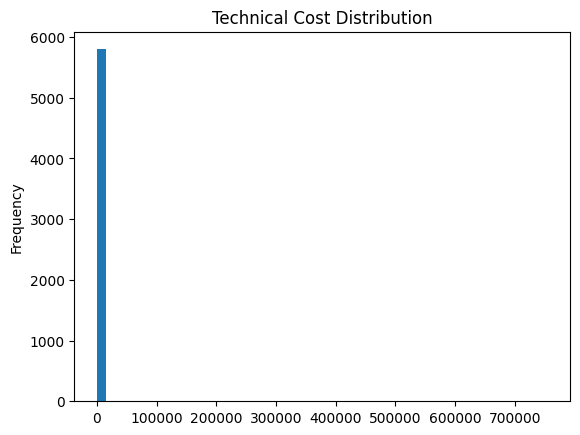

In [52]:
# Make inf or -inf values in technical cost 0
cb_df['technical_cost'] = cb_df['technical_cost'].replace([np.inf, -np.inf], 0)
cb_df["technical_cost"].plot(kind='hist', bins=50, title='Technical Cost Distribution')

In [54]:
cb_df.describe()

,primary_id,future_id,year,air_pollution,technical_cost
count,5.800000e+03,5800.000000,5800.000000,5800.000000,5800.000000
mean,4.380054e+07,100.090000,2036.000000,0.900323,230.020332
std,5.846248e+01,58.462477,8.367322,0.789225,10009.564972
min,4.380044e+07,0.000000,2022.000000,-0.078109,-43.663745
25%,4.380049e+07,49.750000,2029.000000,0.114600,0.000000
50%,4.380054e+07,99.500000,2036.000000,0.793287,0.000000
75%,4.380059e+07,151.250000,2043.000000,1.482564,58.376152
max,4.380064e+07,201.000000,2050.000000,3.469385,755533.017587


## LHS Data

In [55]:
lhs_df_merged = lhs_df_merged.drop(columns=["design_id", "region"])
lhs_df_merged.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
100000,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
100001,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
100002,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
100003,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
100004,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


## Transform time series format into single-row format

### SISEPUEDE Emission data

In [59]:
# Keep only the primary_id, time_period, and emission_total columns
la_emission_total_df = decomposed_df[["primary_id", "time_period", "total_emissions"]]
la_emission_total_df.head()

,primary_id,time_period,total_emissions
0,36800368,7,192.501062
1,36800368,8,187.719262
2,36800368,9,189.224632
3,36800368,10,189.818129
4,36800368,11,190.762750


In [60]:
la_emission_total_df.tail()

,primary_id,time_period,total_emissions
5795,43800638,31,144.204216
5796,43800638,32,142.717148
5797,43800638,33,141.317400
5798,43800638,34,139.986321
5799,43800638,35,139.746886


### Emission data sum

In [61]:
# aggregate data by primary_id summing the emissions
la_emission_df_sum_agg = la_emission_total_df.groupby(["primary_id"]).sum().reset_index()

# Drop time period column
la_emission_df_sum_agg = la_emission_df_sum_agg.drop(columns=["time_period"])
la_emission_df_sum_agg.head()

,primary_id,total_emissions
0,36800368,2517.359006
1,43800438,3072.011568
2,43800439,6450.512091
3,43800440,6683.626925
4,43800441,5766.140732


### Emission data mean

In [62]:
# Filter out rows with time_period < 31
la_filtered_emission_total_df = la_emission_total_df[la_emission_total_df["time_period"] >= 31]
la_filtered_emission_total_df = la_filtered_emission_total_df.reset_index(drop=True)
la_filtered_emission_total_df.head(7)

,primary_id,time_period,total_emissions
0,36800368,31,94.397525
1,36800368,32,100.346579
2,36800368,33,106.657033
3,36800368,34,113.328995
4,36800368,35,118.237396
5,43800438,31,7.272509
6,43800438,32,0.201557


In [64]:
# aggregate data by primary_id by summing the emissions
la_emission_df_mean_agg = la_filtered_emission_total_df.groupby(["primary_id"]).mean().reset_index()

# Rename emission_total to emission_avg_last_five_years
la_emission_df_mean_agg.rename(columns={"total_emissions": "emission_avg_last_five_years"}, inplace=True)
la_emission_df_mean_agg

,primary_id,time_period,emission_avg_last_five_years
0,36800368,33.0,106.593506
1,43800438,33.0,-6.239383
2,43800439,33.0,228.689851
3,43800440,33.0,251.347424
4,43800441,33.0,184.690777
...,...,...,...
195,43800634,33.0,126.369391
196,43800635,33.0,126.241610
197,43800636,33.0,176.445196
198,43800637,33.0,138.617122


In [65]:
# Drop year column as it is no longer needed
la_emission_df_mean_agg = la_emission_df_mean_agg.drop(columns=["time_period"])
la_emission_df_mean_agg.head()

,primary_id,emission_avg_last_five_years
0,36800368,106.593506
1,43800438,-6.239383
2,43800439,228.689851
3,43800440,251.347424
4,43800441,184.690777


### Combining emission agg into one df

In [66]:
print("la_emission_df_mean_agg shape:", la_emission_df_mean_agg.shape)
print("la_emission_df_sum_agg shape:", la_emission_df_sum_agg.shape)

la_emission_df_mean_agg shape: (200, 2)
la_emission_df_sum_agg shape: (200, 2)


In [67]:
la_emissions_df_merged = la_emission_df_mean_agg.merge(la_emission_df_sum_agg, on="primary_id", how="inner")
la_emissions_df_merged.head()

,primary_id,emission_avg_last_five_years,total_emissions
0,36800368,106.593506,2517.359006
1,43800438,-6.239383,3072.011568
2,43800439,228.689851,6450.512091
3,43800440,251.347424,6683.626925
4,43800441,184.690777,5766.140732


In [68]:
print("la_emission_df_mean_agg shape:", la_emission_df_mean_agg.shape)

la_emission_df_mean_agg shape: (200, 2)


### Production Data

In [69]:
# Sum all the subsector emission columns across axis=1
la_production_total_df = industrial_production_df.copy()
la_production_total_df["production_total"] = la_production_total_df[industry_value_fuel_vars].sum(axis=1)
la_production_total_df.head()

,primary_id,time_period,totalvalue_enfu_fuel_consumed_inen_fuel_biomass,totalvalue_enfu_fuel_consumed_inen_fuel_coal,totalvalue_enfu_fuel_consumed_inen_fuel_coke,totalvalue_enfu_fuel_consumed_inen_fuel_diesel,totalvalue_enfu_fuel_consumed_inen_fuel_electricity,totalvalue_enfu_fuel_consumed_inen_fuel_furnace_gas,totalvalue_enfu_fuel_consumed_inen_fuel_gasoline,totalvalue_enfu_fuel_consumed_inen_fuel_hydrocarbon_gas_liquids,totalvalue_enfu_fuel_consumed_inen_fuel_hydrogen,totalvalue_enfu_fuel_consumed_inen_fuel_kerosene,totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas,totalvalue_enfu_fuel_consumed_inen_fuel_oil,production_total
0,36800368,7,1262.298646,3.671070,0.404062,178.601128,1174.317781,5.268705e+07,181.622909,0,0.317356,0,1997.361189,276.982160,5.269212e+07
1,36800368,8,1251.052218,0.581992,0.061134,182.504394,1145.385420,5.254285e+07,175.198697,0,0.356350,0,1756.982222,290.281161,5.254766e+07
2,36800368,9,1245.665599,0.235821,0.022939,194.993152,1136.290977,5.163389e+07,180.826891,0,0.374174,0,1717.637258,310.608648,5.163868e+07
3,36800368,10,1229.758025,0.195703,0.018743,195.487695,1113.543102,5.045960e+07,180.184554,0,0.402038,0,1748.397107,310.009898,5.046438e+07
4,36800368,11,1209.681771,0.153169,0.014263,195.467729,1104.997405,4.920852e+07,177.840154,0,0.424731,0,1784.410018,304.599276,4.921330e+07


In [70]:
# Keep only the primary_id, time_period, and emission_total columns
la_production_total_df = la_production_total_df[["primary_id", "time_period", "production_total"]]
la_production_total_df.head()

,primary_id,time_period,production_total
0,36800368,7,5.269212e+07
1,36800368,8,5.254766e+07
2,36800368,9,5.163868e+07
3,36800368,10,5.046438e+07
4,36800368,11,4.921330e+07


In [71]:
# aggregate data by primary_id summing the emissions
la_production_df_sum_agg = la_production_total_df.groupby(["primary_id"]).sum().reset_index()

# Drop time period column
la_production_df_sum_agg = la_production_df_sum_agg.drop(columns=["time_period"])
la_production_df_sum_agg.head()

,primary_id,production_total
0,36800368,1.288242e+09
1,43800438,7.124875e+08
2,43800439,1.089195e+09
3,43800440,1.063473e+09
4,43800441,1.047608e+09


In [72]:
la_production_df_sum_agg.shape

(200, 2)

### Production Cost Data

In [73]:
industry_cost_vars = [
    c for c in ind_fuel_demand_by_sector.columns
    if c.startswith("energy_demand_capex_") or c.startswith("energy_demand_opex_")
]

In [74]:
ind_fuel_demand_by_sector[industry_cost_vars]

,energy_demand_capex_chemicals_coal,energy_demand_opex_chemicals_coal,energy_demand_capex_glass_coal,energy_demand_opex_glass_coal,energy_demand_capex_mining_coal,energy_demand_opex_mining_coal,energy_demand_capex_other_product_manufacturing_coal,energy_demand_opex_other_product_manufacturing_coal,energy_demand_capex_wood_coal,energy_demand_opex_wood_coal,...,energy_demand_capex_mining_oil,energy_demand_opex_mining_oil,energy_demand_capex_other_product_manufacturing_oil,energy_demand_opex_other_product_manufacturing_oil,energy_demand_capex_plastic_oil,energy_demand_opex_plastic_oil,energy_demand_capex_rubber_and_leather_oil,energy_demand_opex_rubber_and_leather_oil,energy_demand_capex_wood_oil,energy_demand_opex_wood_oil
0,645459.343977,242047.253992,6080.293894,2280.110210,1767.833278,662.937479,6553.929369,2457.723513,37306.928488,13990.098183,...,131459.510316,49297.316368,51815.362954,19430.761108,779719.332924,292394.749847,124912.074038,46842.027764,1.930689e+06,724008.208766
1,61712.943425,23142.353784,4966.585538,1862.469577,1387.020886,520.132832,6175.352220,2315.757083,38840.136502,14565.051188,...,120257.643686,45096.616382,54769.061601,20538.398100,787120.223762,295170.083911,128433.029088,48162.385908,1.880348e+06,705130.527630
2,0.000000,0.000000,4802.984705,1801.119264,1049.752826,393.657310,5822.429379,2183.411017,35068.935024,13150.850634,...,108794.637910,40797.989216,57862.308602,21698.365726,797321.423344,298995.533754,132475.520039,49678.320015,1.815382e+06,680768.281295
3,0.000000,0.000000,4726.690851,1772.509069,680.143581,255.053843,5435.894047,2038.460268,28532.993584,10699.872594,...,97036.427955,36388.660483,61298.374448,22986.890418,791895.271016,296960.726631,134238.504762,50339.439286,1.749552e+06,656082.065166
4,0.000000,0.000000,4402.833267,1651.062475,250.677559,94.004085,5058.656082,1896.996031,21525.994469,8072.247926,...,85072.375997,31902.140999,64926.828759,24347.560784,767252.343702,287719.628888,133015.459640,49880.797365,1.689624e+06,633609.070712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5795,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2530.414151,948.905307,0.000000,0.000000,0.000000,0.000000,6.477848e+05,242919.300739
5796,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2701.640708,1013.115265,0.000000,0.000000,0.000000,0.000000,6.089108e+05,228341.548856
5797,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2882.996458,1081.123672,0.000000,0.000000,0.000000,0.000000,5.711345e+05,214175.435808
5798,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,3074.915680,1153.093380,0.000000,0.000000,0.000000,0.000000,5.344279e+05,200410.475124


In [75]:
# Sum all the subsector emission columns across axis=1
la_production_cost_total_df = ind_fuel_demand_by_sector.copy()
la_production_cost_total_df["production_cost_total"] = la_production_cost_total_df[industry_cost_vars].sum(axis=1)
la_production_cost_total_df.head()

,primary_id,time_period,energy_demand_chemicals_coal,energy_demand_capex_chemicals_coal,energy_demand_opex_chemicals_coal,efficiency_energy_saving_chemicals_coal,efficiency_capex_chemicals_coal,efficiency_opex_chemicals_coal,energy_demand_glass_coal,energy_demand_capex_glass_coal,...,efficiency_energy_saving_rubber_and_leather_oil,efficiency_capex_rubber_and_leather_oil,efficiency_opex_rubber_and_leather_oil,energy_demand_wood_oil,energy_demand_capex_wood_oil,energy_demand_opex_wood_oil,efficiency_energy_saving_wood_oil,efficiency_capex_wood_oil,efficiency_opex_wood_oil,production_cost_total
0,36800368,7,0.580449,645459.343977,242047.253992,0.000000,0.000000e+00,0.0,0.005468,6080.293894,...,0.000000,0.000000,0.0,1.736232,1.930689e+06,724008.208766,0.000000,0.000000e+00,0.0,5.936522e+08
1,36800368,8,0.055497,61712.943425,23142.353784,0.871783,8.717828e+06,0.0,0.004466,4966.585538,...,-0.003590,-35901.014156,-0.0,1.690962,1.880348e+06,705130.527630,0.069119,6.911876e+05,0.0,5.863199e+08
2,36800368,9,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.004319,4802.984705,...,-0.007767,-77668.821278,-0.0,1.632539,1.815382e+06,680768.281295,0.155047,1.550471e+06,0.0,5.935173e+08
3,36800368,10,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.004251,4726.690851,...,-0.009218,-92180.612135,-0.0,1.573339,1.749552e+06,656082.065166,0.241342,2.413419e+06,0.0,5.936549e+08
4,36800368,11,0.000000,0.000000,0.000000,0.963538,9.635383e+06,0.0,0.003959,4402.833267,...,-0.007146,-71458.907169,-0.0,1.519447,1.689624e+06,633609.070712,0.320044,3.200435e+06,0.0,5.948296e+08


In [76]:
# Keep only the primary_id, time_period, and emission_total columns
la_production_cost_total_df = la_production_cost_total_df[["primary_id", "time_period", "production_cost_total"]]
la_production_cost_total_df.head()

,primary_id,time_period,production_cost_total
0,36800368,7,5.936522e+08
1,36800368,8,5.863199e+08
2,36800368,9,5.935173e+08
3,36800368,10,5.936549e+08
4,36800368,11,5.948296e+08


In [77]:
# aggregate data by primary_id summing the emissions
la_production_cost_df_sum_agg = la_production_cost_total_df.groupby(["primary_id"]).sum().reset_index()

# Drop time period column
la_production_cost_df_sum_agg = la_production_cost_df_sum_agg.drop(columns=["time_period"])
la_production_cost_df_sum_agg.head()

,primary_id,production_cost_total
0,36800368,2.745217e+10
1,43800438,2.832977e+10
2,43800439,2.896456e+10
3,43800440,2.665439e+10
4,43800441,2.947961e+10


In [78]:
la_production_df_sum_agg.shape

(200, 2)

### CB data

In [79]:
# aggregate data by primary_id and region by summing the technical cost
cb_df_agg = cb_df.groupby(["primary_id", "future_id"]).sum().reset_index()
cb_df_agg

,primary_id,future_id,strategy_code,year,air_pollution,technical_cost
0,43800438,0,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,44.845002,0.000000
1,43800439,1,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,31.872189,0.000000
2,43800440,2,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,13.453895,0.000000
3,43800441,3,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,20.233116,0.000000
4,43800442,4,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,20.155143,0.000000
...,...,...,...,...,...,...
195,43800635,197,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,32.476778,2020.287578
196,43800636,198,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,28.627057,2412.571971
197,43800637,199,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,37.993797,2605.979469
198,43800638,200,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,59044.0,30.917831,1623.061507


In [80]:
# Drop year column as it is no longer needed
cb_df_agg = cb_df_agg.drop(columns=["year"], errors='ignore')
cb_df_agg.head()

,primary_id,future_id,strategy_code,air_pollution,technical_cost
0,43800438,0,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,44.845002,0.0
1,43800439,1,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,31.872189,0.0
2,43800440,2,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,13.453895,0.0
3,43800441,3,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.233116,0.0
4,43800442,4,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.155143,0.0


In [81]:
cb_df_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   primary_id      200 non-null    int64  
 1   future_id       200 non-null    int64  
 2   strategy_code   200 non-null    object 
 3   air_pollution   200 non-null    float64
 4   technical_cost  200 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 7.9+ KB


## Merge emissions and cb data with lhs samples

In [83]:
attr_primary_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
attr_primary_df

,primary_id,design_id,strategy_id,future_id
0,36800368,4,0,0
1,43800438,4,6004,0
2,43800439,4,6004,1
3,43800440,4,6004,2
4,43800441,4,6004,3
...,...,...,...,...
99997,43900434,4,6004,99996
99998,43900435,4,6004,99997
99999,43900436,4,6004,99998
100000,43900437,4,6004,99999


In [84]:
# Check for duplicates in primary_id
duplicates_primary = attr_primary_df[attr_primary_df.duplicated(subset=["primary_id"], keep=False)]
if not duplicates_primary.empty:
    print("Duplicated primary_id found:")
    print(duplicates_primary)
else:
    print("No duplicated primary_id found.")

# Check for duplicates in future_id
duplicates_future = attr_primary_df[attr_primary_df.duplicated(subset=["future_id"], keep=False)]
if not duplicates_future.empty:
    print("Duplicated future_id found:")
    print(duplicates_future)
else:
    print("No duplicated future_id found.")


No duplicated primary_id found.
Duplicated future_id found:
   primary_id  design_id  strategy_id  future_id
0    36800368          4            0          0
1    43800438          4         6004          0


In [85]:
la_emission_df_w_future_id = la_emissions_df_merged.merge(attr_primary_df, on="primary_id", how="inner")

# Drop design_id and stratgy_id columns
la_emission_df_w_future_id = la_emission_df_w_future_id.drop(columns=["design_id", "strategy_id"])
la_emission_df_w_future_id

,primary_id,emission_avg_last_five_years,total_emissions,future_id
0,36800368,106.593506,2517.359006,0
1,43800438,-6.239383,3072.011568,0
2,43800439,228.689851,6450.512091,1
3,43800440,251.347424,6683.626925,2
4,43800441,184.690777,5766.140732,3
...,...,...,...,...
195,43800634,126.369391,4914.572237,196
196,43800635,126.241610,5062.267166,197
197,43800636,176.445196,5599.383193,198
198,43800637,138.617122,5153.189080,199


In [86]:
la_ssp_out_df = la_emission_df_w_future_id.merge(la_production_df_sum_agg, on="primary_id", how="inner")
la_ssp_out_df = la_ssp_out_df.merge(la_production_cost_df_sum_agg, on="primary_id", how="inner")
la_ssp_out_df.head()

,primary_id,emission_avg_last_five_years,total_emissions,future_id,production_total,production_cost_total
0,36800368,106.593506,2517.359006,0,1.288242e+09,2.745217e+10
1,43800438,-6.239383,3072.011568,0,7.124875e+08,2.832977e+10
2,43800439,228.689851,6450.512091,1,1.089195e+09,2.896456e+10
3,43800440,251.347424,6683.626925,2,1.063473e+09,2.665439e+10
4,43800441,184.690777,5766.140732,3,1.047608e+09,2.947961e+10


In [87]:
# Check that the shape is correct
print("la_ssp_out_df shape:", la_ssp_out_df.shape)
print("la_emission_df_w_future_id shape:", la_emission_df_w_future_id.shape)
print("la_production_df_sum_agg shape:", la_production_df_sum_agg.shape)
print("la_production_cost_df_sum_agg shape:", la_production_cost_df_sum_agg.shape)

la_ssp_out_df shape: (200, 6)
la_emission_df_w_future_id shape: (200, 4)
la_production_df_sum_agg shape: (200, 2)
la_production_cost_df_sum_agg shape: (200, 2)


In [88]:
la_ssp_out_df.isna().sum()

primary_id                      0
emission_avg_last_five_years    0
total_emissions                 0
future_id                       0
production_total                0
production_cost_total           0
dtype: int64

In [89]:
lhs_df_merged.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1761,1762,1767,1768,1770,1778,1780,1792,1793,1801
100000,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.814377,0.142605,0.097383,0.613217,0.746290,0.004296,0.883196,0.430823,0.480203,0.542153
100001,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.945452,0.596037,0.761325,0.972692,0.957930,0.178317,0.059578,0.241647,0.867341,0.299005
100002,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.564013,0.843588,0.468507,0.615248,0.581179,0.297995,0.777503,0.309742,0.127848,0.024428
100003,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.521076,0.511969,0.006134,0.423707,0.044680,0.753944,0.089066,0.978027,0.193832,0.578752
100004,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.886965,0.814298,0.761830,0.453373,0.499034,0.864098,0.349058,0.324254,0.655437,0.735588


In [90]:
lhs_emissions_merged_df = pd.merge(lhs_df_merged, la_ssp_out_df, on="future_id", how="inner")
lhs_emissions_merged_df.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1778,1780,1792,1793,1801,primary_id,emission_avg_last_five_years,total_emissions,production_total,production_cost_total
0,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.004296,0.883196,0.430823,0.480203,0.542153,43800439,228.689851,6450.512091,1.089195e+09,2.896456e+10
1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.178317,0.059578,0.241647,0.867341,0.299005,43800440,251.347424,6683.626925,1.063473e+09,2.665439e+10
2,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.297995,0.777503,0.309742,0.127848,0.024428,43800441,184.690777,5766.140732,1.047608e+09,2.947961e+10
3,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.753944,0.089066,0.978027,0.193832,0.578752,43800442,279.158564,7107.472492,9.955428e+08,2.995237e+10
4,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.864098,0.349058,0.324254,0.655437,0.735588,43800443,336.834484,7737.210438,1.074846e+09,3.234731e+10


In [91]:
lhs_emissions_merged_df.shape

(198, 85)

In [92]:
cb_df_agg.head()

,primary_id,future_id,strategy_code,air_pollution,technical_cost
0,43800438,0,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,44.845002,0.0
1,43800439,1,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,31.872189,0.0
2,43800440,2,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,13.453895,0.0
3,43800441,3,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.233116,0.0
4,43800442,4,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.155143,0.0


In [93]:
complete_merged_df = pd.merge(lhs_emissions_merged_df, cb_df_agg, on=["future_id", "primary_id"], how="inner")
complete_merged_df.head()

,future_id,46,47,48,49,50,51,52,53,54,...,1793,1801,primary_id,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,strategy_code,air_pollution,technical_cost
0,1,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,0.958638,...,0.480203,0.542153,43800439,228.689851,6450.512091,1.089195e+09,2.896456e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,31.872189,0.0
1,2,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,0.799062,...,0.867341,0.299005,43800440,251.347424,6683.626925,1.063473e+09,2.665439e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,13.453895,0.0
2,3,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,0.603465,...,0.127848,0.024428,43800441,184.690777,5766.140732,1.047608e+09,2.947961e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.233116,0.0
3,4,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,0.215486,...,0.193832,0.578752,43800442,279.158564,7107.472492,9.955428e+08,2.995237e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.155143,0.0
4,5,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,0.661824,...,0.655437,0.735588,43800443,336.834484,7737.210438,1.074846e+09,3.234731e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,26.887590,0.0


In [94]:
print(complete_merged_df.shape)
print(complete_merged_df.future_id.nunique())

(198, 88)
198


In [95]:
complete_merged_df.isna().sum().sum()

np.int64(0)

In [96]:
# rearrange columns to have future_id and primary_id at the front
cols_order = ["future_id", "primary_id"] + [col for col in complete_merged_df.columns if col not in ["future_id", "primary_id"]]
complete_merged_df = complete_merged_df[cols_order]
complete_merged_df

,future_id,primary_id,46,47,48,49,50,51,52,53,...,1792,1793,1801,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,strategy_code,air_pollution,technical_cost
0,1,43800439,0.775786,0.377356,0.202813,0.354057,0.479164,0.547598,0.030410,0.362738,...,0.430823,0.480203,0.542153,228.689851,6450.512091,1.089195e+09,2.896456e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,31.872189,0.000000
1,2,43800440,0.944874,0.078818,0.631085,0.139342,0.523612,0.070514,0.459840,0.486941,...,0.241647,0.867341,0.299005,251.347424,6683.626925,1.063473e+09,2.665439e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,13.453895,0.000000
2,3,43800441,0.369574,0.173286,0.992486,0.522608,0.428992,0.175113,0.497895,0.892889,...,0.309742,0.127848,0.024428,184.690777,5766.140732,1.047608e+09,2.947961e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.233116,0.000000
3,4,43800442,0.925750,0.316785,0.809788,0.458506,0.133160,0.230921,0.113836,0.084494,...,0.978027,0.193832,0.578752,279.158564,7107.472492,9.955428e+08,2.995237e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,20.155143,0.000000
4,5,43800443,0.861581,0.383317,0.886344,0.865434,0.930659,0.598769,0.931846,0.504623,...,0.324254,0.655437,0.735588,336.834484,7737.210438,1.074846e+09,3.234731e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,26.887590,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,196,43800634,0.030443,0.787324,0.377028,0.209073,0.411203,0.592051,0.015743,0.138576,...,0.885529,0.455432,0.454087,126.369391,4914.572237,1.014620e+09,2.734561e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,25.058264,1765.912793
194,197,43800635,0.959578,0.688823,0.053842,0.470094,0.106557,0.781539,0.385408,0.508779,...,0.975222,0.384000,0.495205,126.241610,5062.267166,8.597654e+08,3.073085e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,32.476778,2020.287578
195,198,43800636,0.478941,0.760461,0.952835,0.210197,0.800764,0.667663,0.956549,0.080887,...,0.695968,0.978196,0.802352,176.445196,5599.383193,8.188117e+08,2.984614e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,28.627057,2412.571971
196,199,43800637,0.939109,0.934535,0.965766,0.929637,0.247722,0.206639,0.274919,0.880976,...,0.549150,0.353670,0.256298,138.617122,5153.189080,7.614506e+08,3.351802e+10,PFLO:ALL_LA_ACTIONSPFLO:ALL_LA_ACTIONSPFLO:ALL...,37.993797,2605.979469


In [98]:
# Check for nans
complete_merged_df.isna().sum().sum()

np.int64(0)

## Filter out irrelevant lhs groups

In [99]:
var_traj_X_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_X.csv"))
var_traj_L_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "VARIABLE_TRAJECTORY_GROUPS_L.csv"))

In [100]:
var_traj_X_df.tail()

,variable,variable_trajectory_group
79,nemomod_entc_variable_cost_pp_solar_usd_per_mwh,57
80,nemomod_entc_variable_cost_pp_wind_usd_per_mwh,57
81,elasticity_trde_mtkm_to_gdp_freight,58
82,elasticity_trde_pkm_to_gdppc_private_and_public,59
83,elasticity_trde_pkm_to_gdppc_regional,59


In [101]:
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group
456,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_paper,45
457,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_plastic,45
458,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,45
459,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_textiles,45
460,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_wood,45


In [102]:
var_traj_groups_X = var_traj_X_df["variable_trajectory_group"].unique()
var_traj_groups_L = var_traj_L_df["variable_trajectory_group"].unique()
print("Variable trajectory groups X:", var_traj_groups_X)
print("Variable trajectory groups L:", var_traj_groups_L)

Variable trajectory groups X: [46 47 48 49 50 51 52 53 54 55 56 57 58 59]
Variable trajectory groups L: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]


In [103]:
# join the var_traj_groups
var_traj_groups_all = var_traj_groups_X.tolist() + var_traj_groups_L.tolist()
var_traj_groups_all = list(set(var_traj_groups_all))  # remove duplicates
print("All variable trajectory groups:", var_traj_groups_all)

All variable trajectory groups: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


In [104]:
# Convert the variable_trajectory_group column to list of strings
relevant_lhs_cols = [str(col) for col in var_traj_groups_all]

In [105]:
df_cols = complete_merged_df.columns.tolist()

# Filter the relevant_lhs_cols to only include those that are in df_cols
relevant_lhs_cols = [col for col in relevant_lhs_cols if col in df_cols]

In [109]:
# filter complete_merged_df to keep only relevant columns
cols_to_keep = ["future_id", "primary_id"] + list(relevant_lhs_cols) + ["emission_avg_last_five_years", "total_emissions", "production_total","production_cost_total","technical_cost", "air_pollution"]
merged_df_filtered = complete_merged_df[cols_to_keep]

In [110]:
print("Original merged DataFrame shape:", complete_merged_df.shape)
print("Filtered merged DataFrame shape:", merged_df_filtered.shape)

Original merged DataFrame shape: (198, 88)
Filtered merged DataFrame shape: (198, 67)


In [111]:
print("Filtered merged DataFrame fields:", merged_df_filtered.columns.tolist())
print("Relevant LHS columns:", relevant_lhs_cols)

Filtered merged DataFrame fields: ['future_id', 'primary_id', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', 'emission_avg_last_five_years', 'total_emissions', 'production_total', 'production_cost_total', 'technical_cost', 'air_pollution']
Relevant LHS columns: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59']


In [112]:
merged_df_filtered.head()

,future_id,primary_id,1,2,3,4,5,6,7,8,...,56,57,58,59,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution
0,1,43800439,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,0.318541,...,0.110602,0.228879,0.023251,0.519864,228.689851,6450.512091,1.089195e+09,2.896456e+10,0.0,31.872189
1,2,43800440,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,0.659673,...,0.890292,0.243776,0.881897,0.307468,251.347424,6683.626925,1.063473e+09,2.665439e+10,0.0,13.453895
2,3,43800441,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,0.492968,...,0.228748,0.148648,0.914823,0.078667,184.690777,5766.140732,1.047608e+09,2.947961e+10,0.0,20.233116
3,4,43800442,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,0.185125,...,0.114697,0.215141,0.400283,0.013558,279.158564,7107.472492,9.955428e+08,2.995237e+10,0.0,20.155143
4,5,43800443,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,0.692139,...,0.042683,0.369231,0.453588,0.800351,336.834484,7737.210438,1.074846e+09,3.234731e+10,0.0,26.887590


## Add variable names to lhs columns

In [113]:
var_traj_L_df.tail()

,transformation_code,variable,variable_field,variable_trajectory_group
456,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_paper,45
457,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_plastic,45
458,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_rubber_leather,45
459,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_textiles,45
460,TX:WASO:INC_RECYCLING,Fraction of Waste Recycled,frac_waso_recycled_wood,45


In [114]:
var_traj_L_df = var_traj_L_df[["variable_field", "variable_trajectory_group"]]
var_traj_L_df = var_traj_L_df.rename(columns={"variable_field": "variable"})
var_traj_L_df.head()

,variable,variable_trajectory_group
0,ef_agrc_anaerobicdom_rice_kg_ch4_ha,1
1,frac_agrc_agriculture_production_lost,2
2,frac_agrc_crop_residues_burned,3
3,frac_agrc_crop_residues_removed,3
4,frac_agrc_no_till_cereals,3


In [115]:
var_traj_X_df.tail()

,variable,variable_trajectory_group
79,nemomod_entc_variable_cost_pp_solar_usd_per_mwh,57
80,nemomod_entc_variable_cost_pp_wind_usd_per_mwh,57
81,elasticity_trde_mtkm_to_gdp_freight,58
82,elasticity_trde_pkm_to_gdppc_private_and_public,59
83,elasticity_trde_pkm_to_gdppc_regional,59


In [116]:
var_traj_all_df = pd.concat([var_traj_X_df, var_traj_L_df], ignore_index=True)
var_traj_all_df

,variable,variable_trajectory_group
0,exports_enfu_pj_fuel_ammonia,46
1,exports_enfu_pj_fuel_coal,46
2,exports_enfu_pj_fuel_crude,46
3,exports_enfu_pj_fuel_diesel,46
4,exports_enfu_pj_fuel_electricity,46
...,...,...
540,frac_waso_recycled_paper,45
541,frac_waso_recycled_plastic,45
542,frac_waso_recycled_rubber_leather,45
543,frac_waso_recycled_textiles,45


In [117]:
# drop duplicates if any
print("Before dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)
var_traj_all_df = var_traj_all_df.drop_duplicates(subset=["variable", "variable_trajectory_group"])
print("After dropping duplicates, var_traj_all_df shape:", var_traj_all_df.shape)

Before dropping duplicates, var_traj_all_df shape: (545, 2)
After dropping duplicates, var_traj_all_df shape: (537, 2)


In [118]:
# check if there are any duplicated variable names
duplicated_vars = var_traj_all_df["variable"].duplicated().any()
if duplicated_vars:
    print("There are duplicated variable names in var_traj_all_df.")
else:
    print("No duplicated variable names in var_traj_all_df.")

No duplicated variable names in var_traj_all_df.


In [119]:
# Filter var_traj_all_df by sample_group in relevant_lhs_cols
relevant_lhs_cols = [int(col) for col in relevant_lhs_cols]
var_traj_all_df = var_traj_all_df[var_traj_all_df["variable_trajectory_group"].isin(relevant_lhs_cols)]
var_traj_all_df = var_traj_all_df.sort_values(by="variable_trajectory_group", ascending=True)
print("After filtering by relevant_lhs_cols, var_traj_all_df shape:", var_traj_all_df.shape)

After filtering by relevant_lhs_cols, var_traj_all_df shape: (537, 2)


In [120]:
def process_variable_prefix(df):
    result = []
    for group, group_df in df.groupby('variable_trajectory_group'):
        variables = group_df['variable'].tolist()
        if len(variables) == 1:
            prefix = variables[0]
        else:
            prefix = os.path.commonprefix(variables)
            # Clean trailing underscores
            prefix = prefix.rstrip('_')
            
        prefix = f"group_{group}_{prefix}"
        result.append({'variable_trajectory_group': group, 'variable_prefix': prefix})
    return pd.DataFrame(result)

prefix_df = process_variable_prefix(var_traj_all_df)
prefix_df

,variable_trajectory_group,variable_prefix
0,1,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha
1,2,group_2_frac_agrc_agriculture_production_lost
2,3,group_3_frac_agrc
3,4,group_4_qty_ccsq_mt_co2_captured_sequestered_b...
4,5,group_5_nemomod_entc_frac_min_share_production...
5,6,group_6_nemomod_en
6,7,group_7_
7,8,group_8_frac_fgtv_drained_and_waste_ch4_flared...
8,9,group_9_efficfactor_enfu_industrial_energy_fuel
9,10,group_10_scalar_inen_energy_demand


In [121]:
# Check for duplicates in variable_trajectory_group and variable_prefix
dups = prefix_df.duplicated(subset=["variable_trajectory_group", "variable_prefix"], keep=False)
if dups.any():
    print("Duplicated variable_trajectory_group and variable_prefix found:")
    print(prefix_df[dups])
else:
    print("No duplicated variable_trajectory_group and variable_prefix found.")

# Check for duplicates in variable_trajectory_group
dups_group = prefix_df.duplicated(subset=["variable_trajectory_group"], keep=False)
if dups_group.any():
    print("Duplicated variable_trajectory_group found:")
    print(prefix_df[dups_group])
else:
    print("No duplicated variable_trajectory_group found.")

# Check for duplicates in variable_prefix
dups_prefix = prefix_df.duplicated(subset=["variable_prefix"], keep=False)
if dups_prefix.any():
    print("Duplicated variable_prefix found:")
    print(prefix_df[dups_prefix])
else:
    print("No duplicated variable_prefix found.")

No duplicated variable_trajectory_group and variable_prefix found.
No duplicated variable_trajectory_group found.
No duplicated variable_prefix found.


In [122]:
# var_traj_all_df[var_traj_all_df["variable_trajectory_group"].isin([3, 13, 40])]

In [123]:
# prefix_df.loc[prefix_df["sample_group"] == 13, "variable_prefix"] = "group_13_frac_gnrl_eating_red_meats+"
# prefix_df.loc[prefix_df["sample_group"] == 40, "variable_prefix"] = "group_40_pij_lndu_grasslands+"

# prefix_df = prefix_df.sort_values(by="variable_prefix", ascending=True)
# prefix_df

In [124]:
# Let's use the prefix_df to rename the columns in merged_df_filtered
def rename_columns_with_prefix(merged_df, prefix_df):
    df = merged_df.copy()
    # Create a mapping from str(group) to prefix
    group_to_prefix = {str(row['variable_trajectory_group']): row['variable_prefix'] for _, row in prefix_df.iterrows()}
    # Only rename columns that match a group
    rename_dict = {col: group_to_prefix[col] for col in df.columns if col in group_to_prefix}
    df = df.rename(columns=rename_dict)
    return df

merged_df_filtered_w_prefix = rename_columns_with_prefix(merged_df_filtered, prefix_df)

In [125]:
merged_df_filtered_w_prefix

,future_id,primary_id,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,...,group_56_nemomod_entc,group_57_nemomod_entc,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution
0,1,43800439,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,0.318541,...,0.110602,0.228879,0.023251,0.519864,228.689851,6450.512091,1.089195e+09,2.896456e+10,0.000000,31.872189
1,2,43800440,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,0.659673,...,0.890292,0.243776,0.881897,0.307468,251.347424,6683.626925,1.063473e+09,2.665439e+10,0.000000,13.453895
2,3,43800441,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,0.492968,...,0.228748,0.148648,0.914823,0.078667,184.690777,5766.140732,1.047608e+09,2.947961e+10,0.000000,20.233116
3,4,43800442,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,0.185125,...,0.114697,0.215141,0.400283,0.013558,279.158564,7107.472492,9.955428e+08,2.995237e+10,0.000000,20.155143
4,5,43800443,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,0.692139,...,0.042683,0.369231,0.453588,0.800351,336.834484,7737.210438,1.074846e+09,3.234731e+10,0.000000,26.887590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,196,43800634,0.400366,0.986010,0.361522,0.616053,0.602973,0.323046,0.406400,0.331538,...,0.849351,0.911035,0.597307,0.298302,126.369391,4914.572237,1.014620e+09,2.734561e+10,1765.912793,25.058264
194,197,43800635,0.530322,0.761829,0.211636,0.987435,0.933932,0.907629,0.654732,0.432305,...,0.919679,0.854327,0.269663,0.393196,126.241610,5062.267166,8.597654e+08,3.073085e+10,2020.287578,32.476778
195,198,43800636,0.485488,0.194220,0.390098,0.924337,0.754039,0.201067,0.145475,0.840033,...,0.629466,0.863630,0.730555,0.626368,176.445196,5599.383193,8.188117e+08,2.984614e+10,2412.571971,28.627057
196,199,43800637,0.230425,0.427640,0.450050,0.584992,0.755973,0.867327,0.202307,0.578901,...,0.858530,0.952313,0.997904,0.467450,138.617122,5153.189080,7.614506e+08,3.351802e+10,2605.979469,37.993797


In [126]:
print(merged_df_filtered.shape)
print(merged_df_filtered_w_prefix.shape)

(198, 67)
(198, 67)


In [127]:
# check for duplicated column names
duplicated_cols = merged_df_filtered_w_prefix.columns[merged_df_filtered_w_prefix.columns.duplicated()].tolist()
if duplicated_cols:
    print("Duplicated column names found:", duplicated_cols)
else:
    print("No duplicated column names found.")

No duplicated column names found.


## Finally we save the processed data as training data

In [128]:
#save the merged DataFrame to a CSV file
merged_df_filtered_w_prefix.to_csv(os.path.join(TRAINING_DIR_PATH, "training_data_v5.3.csv"), index=False)